# ov.synbio III — CRISPR editing & directed-evolution libraries

A focused tour of two synbio workflows that `ov.synbio` supports end-to-end:

1. **CRISPR editing** — design guide RNAs for a gene, screen their specificity, and plan base edits / HDR knock-ins.
2. **Directed evolution** — design mutant libraries (degenerate codons, DMS) and let a protein language model *guide* which variants to build.

We work on a real protein — the 56-residue **GB1 domain** — and use `ov.synbio` itself to turn it into a gene, so the whole notebook is self-contained. The CRISPR/library parts are CPU-only; the model-guided step uses ESM (GPU when available).

`pip install 'omicverse[synbio]'`.

In [1]:
import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


First, turn the GB1 protein into a codon-optimized *E. coli* gene — this is the DNA we will target with CRISPR.

gene length: 168 bp


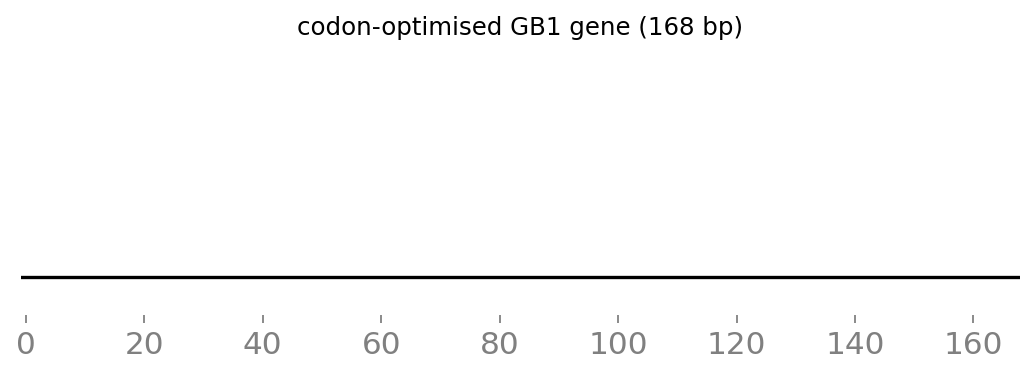

In [2]:
GB1 = 'MTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTE'
gene = ov.synbio.codon_optimize(GB1, host='e_coli').sequence
print('gene length:', len(gene), 'bp')
ov.synbio.view_construct(gene, title='codon-optimised GB1 gene')   # the CRISPR target, as a map
None

## 1 — Guide-RNA design

`design_grnas` scans both strands for SpCas9 `NGG` PAM sites, extracts 20-nt protospacers, filters on GC, and ranks them by an on-target efficiency heuristic (GC, poly-T terminators, PAM-proximal G).

In [3]:
guides = ov.synbio.design_grnas(gene, enzyme='SpCas9')
print(f'{len(guides)} candidate guides; best 3:')
for g in guides[:3]:
    print(' ', g)

18 candidate guides; best 3:
  Guide(GTATGCGAACGATAACGGCG TGG +@95 GC=0.55 eff=1.00)
  Guide(AGGCGAAACCACCACCGAAG CGG +@38 GC=0.60 eff=0.97)
  Guide(CTGAACGGCAAAACCCTGAA AGG +@18 GC=0.50 eff=0.95)


**Compare algorithms.** The ranking above uses `method='heuristic'` (GC / poly-T rules). `method='rs3'` scores each guide with the **real Rule Set 3 model** (DeWeirdt 2021) — the maintained successor to Azimuth / Rule Set 2 — which can re-rank the guides based on the trained on-target model.

Calculating sequence-based features


  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:00<00:00, 3047.02it/s]

heuristic top: GTATGCGAACGATAACGGCG score=1.00
rs3 (real) top: GTATGCGAACGATAACGGCG score=1.07  (Rule Set 3 z-score)


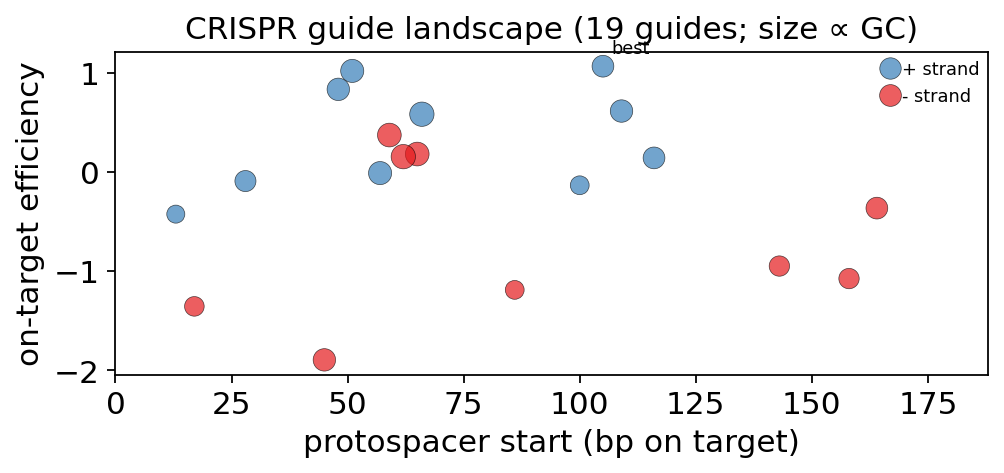

In [4]:
# on-target: heuristic vs the REAL Rule Set 3 model (Azimuth's successor) — side by side
flanked = 'GCATGCATGC' + gene + 'GCATGCATGC'    # flanks so guides get a full 30-mer context
gh = ov.synbio.design_grnas(flanked, method='heuristic')
gr = ov.synbio.design_grnas(flanked, method='rs3')
print(f"heuristic top: {gh[0].spacer} score={gh[0].efficiency:.2f}")
print(f"rs3 (real) top: {gr[0].spacer} score={gr[0].efficiency:.2f}  (Rule Set 3 z-score)")
# the real Rule Set 3 landscape along the gene (efficiency = trained-model score)
ov.synbio.plot_grna_efficiency(gr, target_len=len(flanked))
None

`plot_grna_efficiency` maps the candidates along the gene — position vs efficiency, coloured by strand, sized by GC — so you can pick a well-placed, efficient guide.

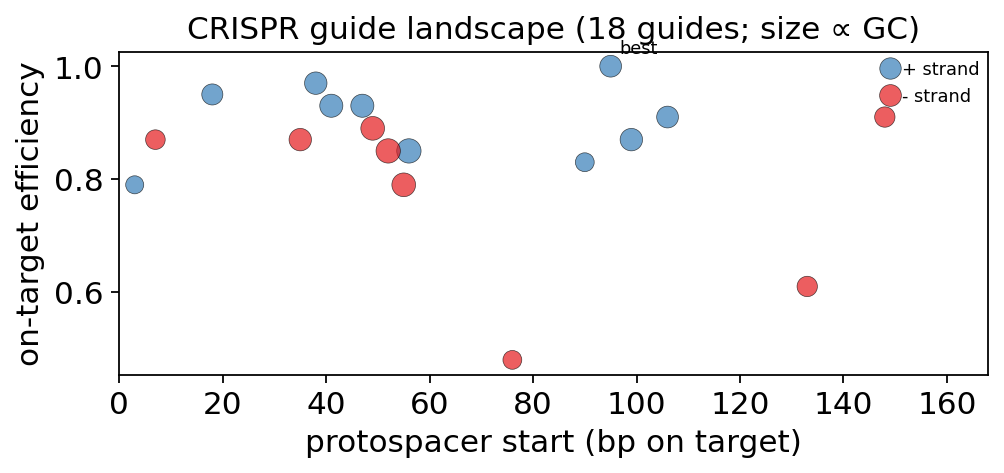

In [5]:
ov.synbio.plot_grna_efficiency(guides, target_len=len(gene))
None

## 2 — Off-target specificity

A guide is only useful if it's specific. `offtarget_search` finds near-matches (here in a synthetic background carrying a few decoy sites) and scores them with a seed-weighted, CFD-style model — mismatches in the PAM-proximal seed hurt far more than distal ones.

In [6]:
spacer = guides[0].spacer
# build a background with the on-target plus 3 decoys carrying 1-3 seed/distal mismatches
decoys = [spacer, 'A' + spacer[1:], spacer[:10] + 'AA' + spacer[12:], spacer[:-3] + 'AAA']
background = 'GC'.join(d + 'TGG' for d in decoys) + gene
offs = ov.synbio.offtarget_search(spacer, background, max_mismatches=4)
print(f'{len(offs)} sites; top:')
for o in offs[:4]:
    print(' ', o)

5 sites; top:
  OffTarget(@0+ mm=0 cfd=1.000)
  OffTarget(@50+ mm=1 cfd=1.000)
  OffTarget(@193+ mm=0 cfd=1.000)
  OffTarget(@25+ mm=1 cfd=0.900)


**Compare algorithms.** `method='seed'` is a dependency-free seed-weighted approximation; `method='cfd'` (the default) uses the **real Doench-2016 CFD tables** (240 empirically-measured mismatch factors, vendored from CRISPOR). Note how a PAM-proximal (seed) mismatch is scored very differently by the calibrated CFD.

  mm=0  seed=1.000   CFD(real Doench)=1.000
  mm=0  seed=1.000   CFD(real Doench)=1.000
  mm=1  seed=0.850   CFD(real Doench)=1.000
  mm=1  seed=0.534   CFD(real Doench)=0.900
  mm=3  seed=0.022   CFD(real Doench)=0.278


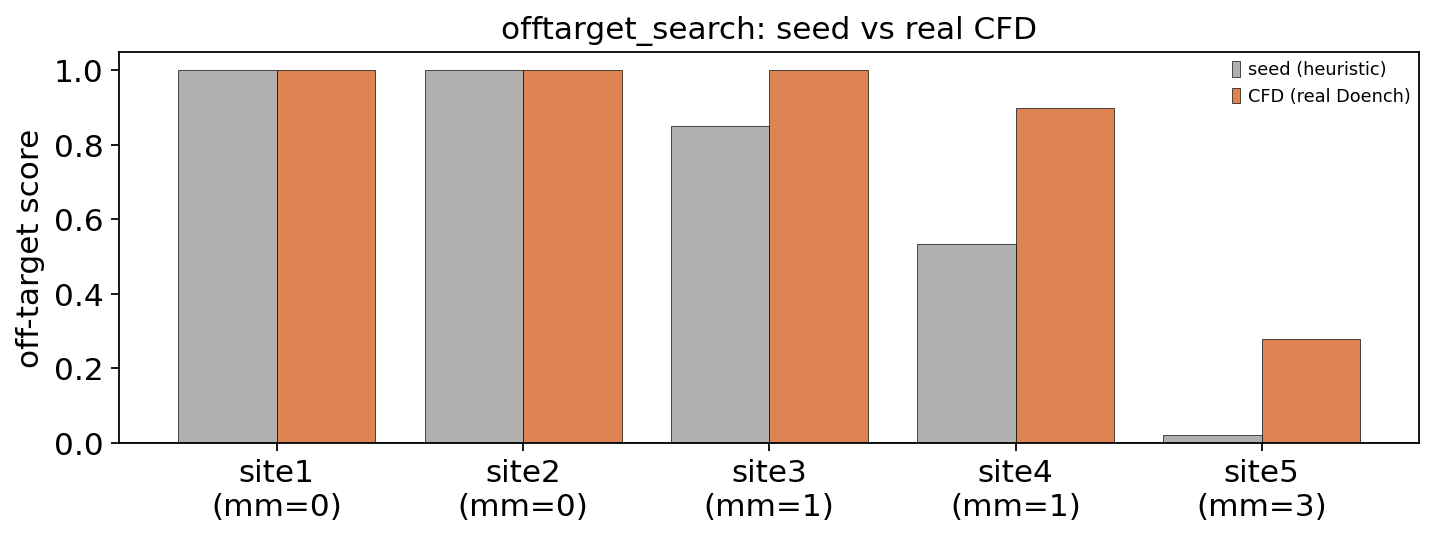

In [7]:
# off-target: seed heuristic vs the REAL Doench-2016 CFD tables — side by side
seed = ov.synbio.offtarget_search(spacer, background, method='seed')
cfd  = ov.synbio.offtarget_search(spacer, background, method='cfd')
labels, sv, cv = [], [], []
for i, (s, c) in enumerate(zip(seed, cfd)):
    print(f"  mm={s.mismatches}  seed={s.cfd:.3f}   CFD(real Doench)={c.cfd:.3f}")
    labels.append(f"site{i+1}\n(mm={s.mismatches})"); sv.append(s.cfd); cv.append(c.cfd)
ov.synbio.plot_method_comparison(labels, {'seed (heuristic)': sv, 'CFD (real Doench)': cv},
    ylabel='off-target score', title='offtarget_search: seed vs real CFD')
None

`plot_offtargets` draws the mismatch matrix — one row per candidate site (ranked by CFD), dark cells where the site differs from the guide. A row with only PAM-distal (left) mismatches is more dangerous than one with seed (right) mismatches.

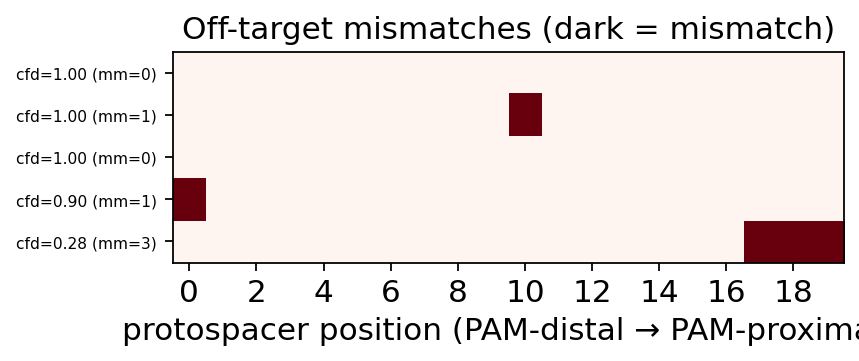

In [8]:
ov.synbio.plot_offtargets(offs, spacer=spacer)
None

## 3 — Base editing & HDR knock-in

Beyond cutting: `base_editor_window` reports which bases an adenine or cytosine base editor could change within its activity window (protospacer positions 4–8), and `hdr_arms` builds a homology-directed-repair donor to insert a payload at the cut site.

In [9]:
print('ABE (A->G):', ov.synbio.base_editor_window(spacer, editor='ABE'))
donor = ov.synbio.hdr_arms(gene, cut_site=len(gene)//2, arm_length=30, insert='CATCATCATCACCATCAC')  # 6xHis
print('HDR donor:', donor['left_len'], 'bp + 6xHis insert +', donor['right_len'], 'bp')

ABE (A->G): {'editor': 'ABE', 'window': (4, 8), 'target_base': 'A', 'n_edits': 1, 'edits': [{'position': 8, 'from': 'A', 'to': 'G'}], 'edited_spacer': 'GTATGCGGACGATAACGGCG'}
HDR donor: 30 bp + 6xHis insert + 30 bp


## 4 — Mutant-library design

To evolve a protein you screen a *library*. `degenerate_codon` finds the minimal IUPAC codon covering a desired amino-acid set (all 20 → NNK/NNS, with no wasted codons), and `saturation_library` / `dms_library` size the experiment.

In [10]:
print('all 20 AA ->', ov.synbio.degenerate_codon(list('ACDEFGHIKLMNPQRSTVWY')))
print('small+polar (A,S,T,G) ->', ov.synbio.degenerate_codon(['A', 'S', 'T', 'G']))
print('3-site NNK saturation:', ov.synbio.saturation_library(3, 'NNK'))
lib = ov.synbio.dms_library(GB1, positions=[3, 5, 27])
print('DMS at 3 positions:', lib['n_variants'], 'single mutants')

all 20 AA -> DegenerateCodon(NNS: 32 codons -> 20 AA, missing=[])
small+polar (A,S,T,G) -> DegenerateCodon(RSC: 4 codons -> 4 AA, missing=[])
3-site NNK saturation: {'scheme': 'NNK', 'positions': 3, 'codons_per_site': 32, 'aa_per_site': 20, 'stop_fraction_per_site': 0.031, 'dna_diversity': 32768, 'protein_diversity': 8000, 'screen_for_95pct': 98304}
DMS at 3 positions: 57 single mutants


## 5 — Model-guided directed evolution

Rather than screen blindly, let a protein language model prioritise. `ml_guided_design` scores every single mutation with an ESM saturation scan, then greedily combines the most-favoured, non-conflicting mutations into ranked multi-mutant designs — a first-round design an experimentalist can order.

F30A+V21A+W43V  predicted score 6.49
F30A+V21A  predicted score 4.45
F30A  predicted score 2.28
F30A  predicted score 2.28


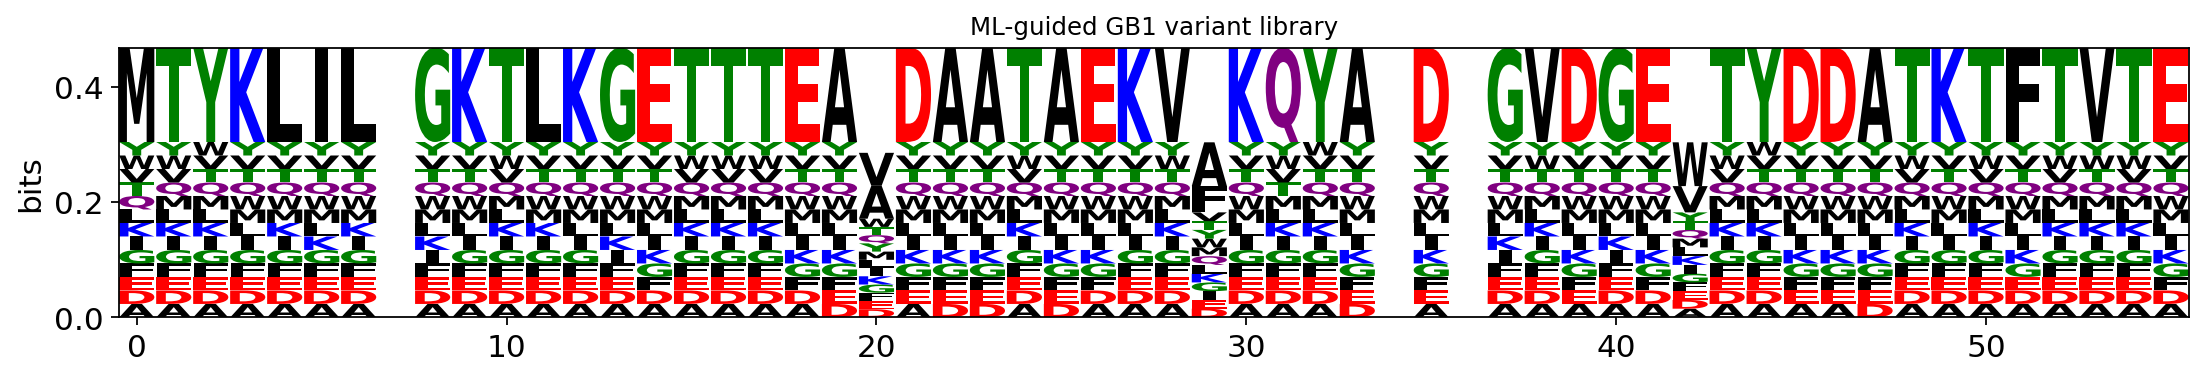

In [11]:
designs = ov.synbio.ml_guided_design(GB1, n_mutations=3, n_designs=6)
for d in designs[:4]:
    print('+'.join(d.mutations), ' predicted score', round(d.predicted_score, 2))
# protein logo over the designed variants — where directed evolution concentrates its edits
ov.synbio.plot_sequence_logo([d.sequence for d in designs], title='ML-guided GB1 variant library')
None

The design is built from the single-mutation landscape — the same ESM saturation scan, shown as a heatmap. Red cells are favoured substitutions; the greedy designer picks the best non-conflicting ones.

[ov.synbio.variant_effect] model=esm1v scoring=masked-marginals device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


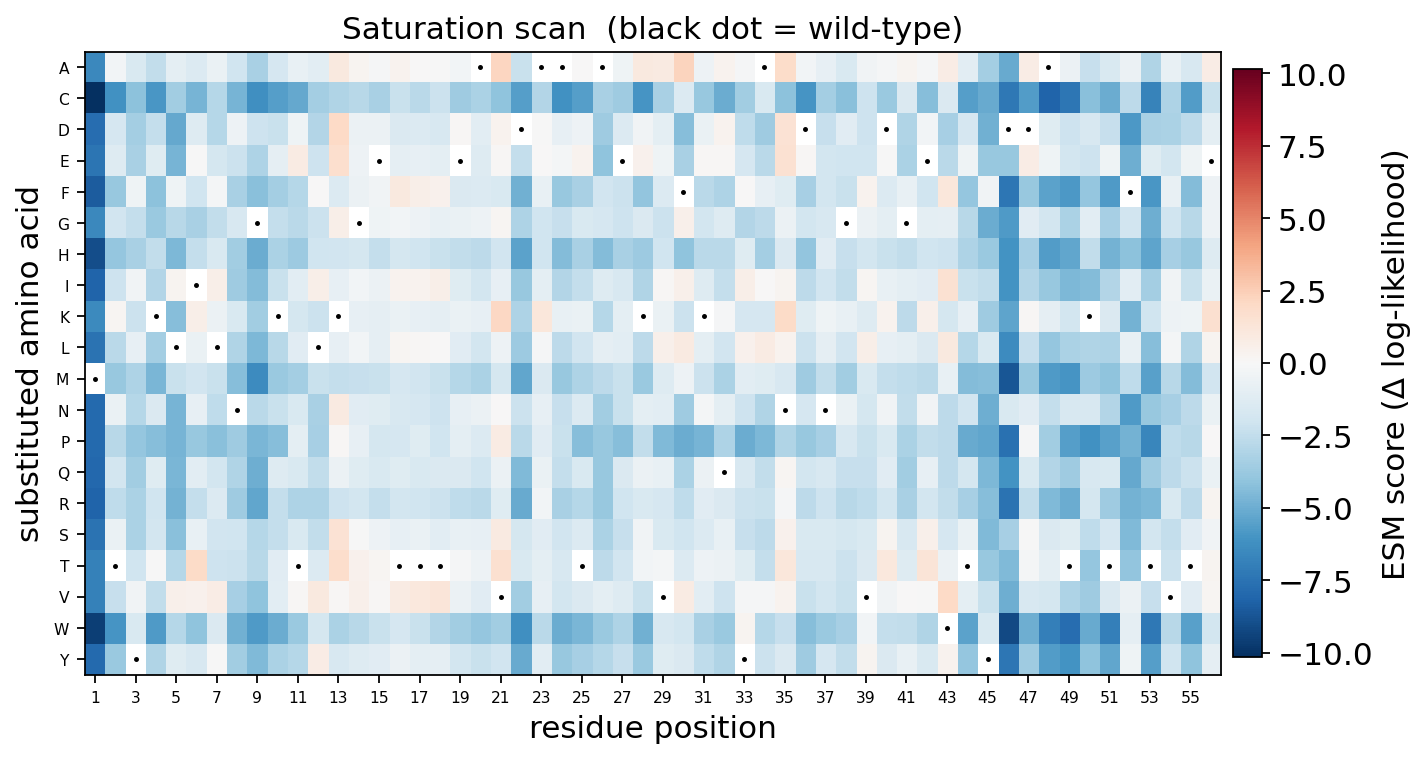

In [12]:
dms = ov.synbio.variant_effect(GB1, model='esm1v')
ov.synbio.plot_variant_effect(dms)
None

## 6 — Confirm the enzyme's function (CLEAN)

Before evolving an enzyme it helps to *confirm what it does*. `enzyme_function` predicts the EC number two ways: `method='knn'` (a light ESM-2 nearest-neighbour vs a small bundled reference) and `method='clean'` — the **real trained CLEAN model** (Yu 2023, contrastive ESM-1b assigned by max-separation against ~5,200 SwissProt EC cluster centres). On the real *E. coli* phosphofructokinase (PfkA), CLEAN returns the correct **EC 2.7.1.11** with high confidence. `plot_ec_prediction` shows the ranked calls.

k-NN baseline : [('2.7.1.11', 0.9837279915809631), ('4.2.1.11', 0.9466314315795898)]
CLEAN (real)  : [('2.7.1.11', 0.9912)]   true EC of PfkA = 2.7.1.11


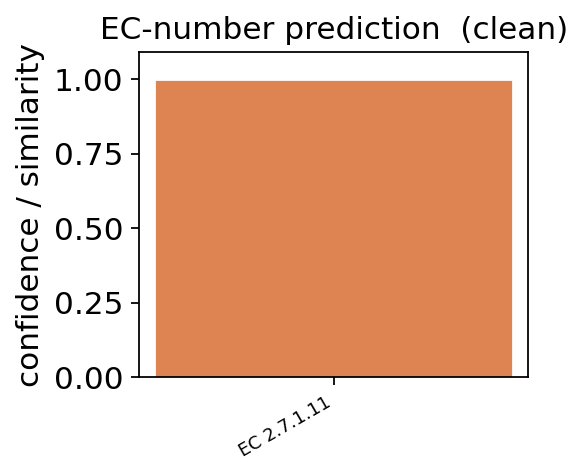

In [13]:
PFKA = ('MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLYEDRMVQLDRYSVSDMINRGGTFLGSARFPEFRD'
        'ENIRAVAIENLKKRGIDALVVIGGDGSYMGAMRLTEMGFPCIGLPGTIDNDIKGTDYTIGFFTALSTVVEAIDRLRDT')
# baseline: ESM-2 k-NN vs a small bundled reference
knn = ov.synbio.enzyme_function(PFKA, method='knn', verbose=False)
# real SOTA: the trained CLEAN model (contrastive ESM-1b vs ~5,200 EC centres)
clean = ov.synbio.enzyme_function(PFKA, method='clean', verbose=False)
print('k-NN baseline :', knn.predictions[:2])
print('CLEAN (real)  :', clean.predictions[:2], '  true EC of PfkA = 2.7.1.11')
ov.synbio.plot_ec_prediction(clean)
None

## Summary

From one protein we designed and scored **CRISPR guides** (with specificity screening and edit planning) and a **directed-evolution campaign** (libraries + model-guided variant selection) — the *build* and *test/learn* arms of the DBTL cycle, entirely inside `ov.synbio`.

Combine with the [core tutorial](t_synbio_01_intro.ipynb) (metabolism ↔ protein ↔ DNA) and [tutorial II](t_synbio_02_circuits_to_pathways.ipynb) (circuits, assembly, pathway design) for the full picture.